In [2]:
from pathlib import Path
import anndata as ad
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
adata_prova = ad.read_h5ad('/home/stefano/Documents/Spatial-Transcriptomic/results/rctd_result/weights/blocco2_c26_anndata.h5ad')

In [ ]:
adata_normalized = adata_prova.copy()
adata_normalized.X = np.expm1(adata_normalized.X)
sc.pp.normalize_total(adata_normalized, target_sum=1.0)

In [14]:
np.sum(adata_normalized.X[200,:], axis=1)

matrix([[10000.]])

In [110]:
adata_prova

AnnData object with n_obs × n_vars = 2690 × 32285
    obs: 'X', 'Y', 'fiber_type'
    uns: 'log1p'
    obsm: 'rctd_weights'

In [12]:
myonuclei = ["Myonuclei_Trim63", "Myonuclei_NMJ", "Myonuclei_MTJ", "Myonuclei_IIx_IIb", "Myonuclei_IIx_IIa", "Myonuclei_IIx", "Myonuclei_IIb"]
myonuclei_marker_genes_list = ["Ache", "Col22a1", "Etv5", "Myh1", "Myh2", "Myh4", "Ttn", "Trim63"]

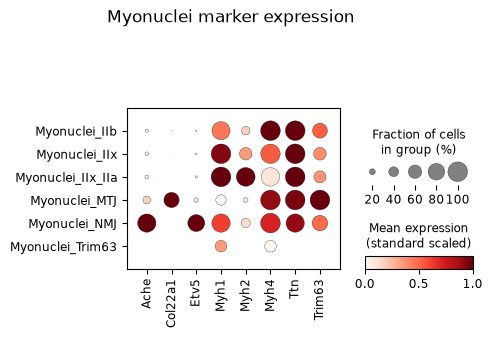

In [ ]:
dp_myonuclei = sc.pl.dotplot(
                adata_rctd[adata_rctd.obs["fiber_type"].isin(myonuclei)],
                var_names = myonuclei_marker_genes_list,
                groupby = "fiber_type",
                use_raw = False, #since we normalize
                standard_scale = 'var',
                colorbar_title='Mean expression\n(standard scaled)',
                title = "Myonuclei marker expression ",
                show=False
        )

In [24]:
myonuclei_fiber_I_marker = ['Ttn', 'Myh1']

In [25]:
expr_matrix = adata_rctd[:, myonuclei_fiber_I_marker].X.toarray()
all_present = np.all(expr_matrix >0, axis=1)
sum_expr = expr_matrix.sum(axis=1)
sum_expr[all_present==False] = 0

# Abbundance of markers used to define myonuclei populations



In [5]:
def get_gene_expr(adata, gene_name):
    if gene_name in adata.var_names:
        col = adata[:, gene_name].X
        col = col.toarray()
        arr = np.asarray(col, dtype=float).ravel()
        return arr
    else:
        print(f'{gene_name} not presente in the dataset')
        return np.zeros(adata.n_obs)



In [ ]:
#each row of the normalized fiber expr matrix is normalized to 10'000 counts, therefore 180 correspond to 1.8% treshold
def assign_by_(adata, min_coexpr_treshold=180):

    adata_normalized = adata.copy()
    adata_normalized.X = np.expm1(adata_normalized.X)
    #sc.pp.normalize_total(adata_normalized, target_sum=1.0)
    genes = list(adata.var_names)

    ttn = get_gene_expr(adata_normalized,'Ttn')
    myh1 = get_gene_expr(adata_normalized,'Myh1')
    myh2 = get_gene_expr(adata_normalized,'Myh2')
    myh4 = get_gene_expr(adata_normalized,'Myh4')
    myh7 = get_gene_expr(adata_normalized, 'Myh7')

    #Calculate the Geometric Co-expression score for each pair which define a myonuclei population
    # sqrt(gene1 * gene2) requires which both are >0 to give a result >0
    IIb = np.sqrt(ttn * myh4) 
    IIx = np.sqrt(ttn * myh1)
    IIa = np.sqrt(ttn * myh2)
    I = np.sqrt(ttn * myh7)
    
    #IIx_IIa = np.maximum(np.sqrt(ttn * myh1) , np.sqrt(ttn * myh2))
    #IIx_IIb = np.maximum(np.sqrt(ttn * myh1) , np.sqrt(ttn * myh4))

    #Matrix with co-expression scores, with shape: n_fibers x 3
    coexpr_matrix = np.column_stack([IIb, IIx, IIa, I])
    #coexpr_matrix = np.column_stack([IIb, IIx, IIx_IIa, IIx_IIb])
    pair_names = ['Myonuclei_IIb', 'Myonuclei_IIx', 'Myonuclei_IIa', 'Myonuclei_I']
    myonuclei={}
    for name in pair_names:
        myonuclei[name] ={'n' : 0,
                          'proportions' : 0}

    labels = []

    for i in range(adata.n_obs):
        scores = coexpr_matrix[i, :]
        max_score = np.max(scores)

        if max_score < min_coexpr_treshold:
            labels.append('Unclassified')
            continue

        #assign the label to the best co-expression score
        best_pair_index = np.argmax(scores)
        #labels.append(pair_names[best_pair_index])
        myonuclei[pair_names[best_pair_index]]['n'] += 1

    #compute the proportions
    for name in pair_names:
        myonuclei[name]['proportions'] = round(myonuclei[name]['n']/adata.n_obs, 4)
    
    #create dataframe from the dict
    df_myonuclei = pd.DataFrame.from_dict(myonuclei, orient="index")
    
    return df_myonuclei


# relative abbundances of markers respect a defined pool of markers used to define myonuclei populations

In [37]:
def assign_myonuclei_types_row_marker_rel_expr(adata, min_coexpr_treshold=0.2):
    """
    Assegna ogni fibra ad una popolazione di Myonuclei basandosi sulla 
    CO-ESPRESSIONE OBBLIGATORIA della coppia di geni marker:
    - IIx: Ttn AND Myh1
    - IIa: Ttn AND Myh2
    - IIb: Ttn AND Myh4

    Want also normalize each row to 1
    """  
    adata_normalized = adata.copy()
    adata_normalized.X = np.expm1(adata_normalized.X)

    #marker_genes = ['Ttn', 'Myh1', 'Myh2', 'Myh4', 'Etv5', 'Col22a1', 'Ache']

    ttn = get_gene_expr(adata_normalized, 'Ttn')
    myh1 = get_gene_expr(adata_normalized, 'Myh1')
    myh2 = get_gene_expr(adata_normalized, 'Myh2')
    myh4 = get_gene_expr(adata_normalized, 'Myh4')
    myh7 = get_gene_expr(adata_normalized, 'Myh7')

    #calculate proportions
    total_marker_expr = ttn + myh1 + myh2 + myh4

    safe_total = np.where(total_marker_expr==0, 1e-6, total_marker_expr) #in oder to avoid 0 division
    rel_ttn = (ttn / safe_total) 
    rel_myh1 = (myh1 / safe_total)
    rel_myh2 = (myh2 / safe_total)
    rel_myh4 = (myh4 / safe_total) 
    rel_myh7 = (myh7/ safe_total)

    #Calculate the Geometric Co-expression score for each pair which define a myonuclei population
    # sqrt(gene1 * gene2) requires which both are >0 to give a result >0
    IIb = np.sqrt(rel_ttn * rel_myh4)
    IIx = np.sqrt(rel_ttn * rel_myh1)
    IIa = np.sqrt(rel_ttn * rel_myh2)
    I = np.sqrt(rel_ttn * rel_myh7)

    #IIx_IIa = np.maximum(np.sqrt(ttn * myh1) , np.sqrt(ttn * myh2))
    #IIx_IIb = np.maximum(np.sqrt(ttn * myh1) , np.sqrt(ttn * myh4))

    #Matrix with co-expression scores, with shape: n_fibers x 3
    coexpr_matrix = np.column_stack([IIb, IIx, IIa, I])
    #coexpr_matrix = np.column_stack([IIb, IIx, IIx_IIa, IIx_IIb])
    pair_names = ['Myonuclei_IIb', 'Myonuclei_IIx', 'Myonuclei_IIa', 'Myonuclei_I']

    myonuclei={}
    for name in pair_names:
        myonuclei[name] ={'n' : 0,
                          'proportions' : 0}

    labels = []

    for i in range(adata.n_obs):
        scores = coexpr_matrix[i, :]
        max_score = np.max(scores)

        if max_score < min_coexpr_treshold:
            labels.append('Unclassified')
            continue

        #assign the label to the best co-expression score
        best_pair_index = np.argmax(scores)
        #labels.append(pair_names[best_pair_index])
        myonuclei[pair_names[best_pair_index]]['n'] += 1

    #compute the proportions
    for name in pair_names:
        myonuclei[name]['proportions'] = round(myonuclei[name]['n']/adata.n_obs, 4)
    
    #create dataframe from the dict
    df_myonuclei = pd.DataFrame.from_dict(myonuclei, orient="index")
    
    return df_myonuclei



In [42]:
okj= assign_myonuclei_types_row_marker_rel_expr(adata_prova, 0.4)

In [43]:
okj

,n,proportions
Myonuclei_IIb,986,0.2333
Myonuclei_IIx,637,0.1507
Myonuclei_IIa,4,0.0009
Myonuclei_I,0,0.0000


# Column scaled marker used to define myonuclei populations

In [48]:
""" Scale a gene to a scale between 0 and 1 using min and max of the correspondent column. Relative abbundance of a gene respect its expression in a sample """
def get_colunn_relative_expr(adata, gene_name):
    if gene_name in adata.var_names:
        col = adata[:, gene_name].X #extract the transcripts count of a given gene from fiber expr matrix
        col = col.toarray()
        arr = np.asarray(col, dtype=float).ravel()

        #Min-Max scaling 
        min_val, max_val = np.min(arr), np.max(arr)
        if max_val > min_val:
            return (arr - min_val)/(max_val - min_val)
        return np.zeros(adata.n_obs, dtype=float)
    else:
        print(f'{gene_name} not presente in the dataset')
        return np.zeros(adata.n_obs)


In [49]:
#try that approach in order to avoid covering of highly expressed marker to low but significantly expressed marker
def assign_myonucley_types_col_scaled_marker_expr(adata, min_coexpr_treshold=0.2):

    adata_normalized = adata.copy()
    adata_normalized.X = np.expm1(adata_normalized.X)
    #sc.pp.normalize_total(adata_normalized, target_sum=1.0)
    genes = list(adata.var_names)

    ttn = get_colunn_relative_expr(adata_normalized,'Ttn')
    myh1 = get_colunn_relative_expr(adata_normalized,'Myh1')
    myh2 = get_colunn_relative_expr(adata_normalized,'Myh2')
    myh4 = get_colunn_relative_expr(adata_normalized,'Myh4')
    myh7 = get_colunn_relative_expr(adata_normalized, 'Myh7')

    #Calculate the Geometric Co-expression score for each pair which define a myonuclei population
    # sqrt(gene1 * gene2) requires which both are >0 to give a result >0
    IIb = np.sqrt(ttn * myh4) 
    IIx = np.sqrt(ttn * myh1)
    IIa = np.sqrt(ttn * myh2)
    I = np.sqrt(ttn * myh7)
    
    #IIx_IIa = np.maximum(np.sqrt(ttn * myh1) , np.sqrt(ttn * myh2))
    #IIx_IIb = np.maximum(np.sqrt(ttn * myh1) , np.sqrt(ttn * myh4))

    #Matrix with co-expression scores, with shape: n_fibers x 3
    coexpr_matrix = np.column_stack([IIb, IIx, IIa, I])
    #coexpr_matrix = np.column_stack([IIb, IIx, IIx_IIa, IIx_IIb])
    pair_names = ['Myonuclei_IIb', 'Myonuclei_IIx', 'Myonuclei_IIa', 'Myonuclei_I']
    myonuclei={}
    for name in pair_names:
        myonuclei[name] ={'n' : 0,
                          'proportions' : 0}

    labels = []

    for i in range(adata.n_obs):
        scores = coexpr_matrix[i, :]
        max_score = np.max(scores)

        if max_score < min_coexpr_treshold:
            labels.append('Unclassified')
            continue

        #assign the label to the best co-expression score
        best_pair_index = np.argmax(scores)
        #labels.append(pair_names[best_pair_index])
        myonuclei[pair_names[best_pair_index]]['n'] += 1

    #compute the proportions
    for name in pair_names:
        myonuclei[name]['proportions'] = round(myonuclei[name]['n']/adata.n_obs, 4)
    
    #create dataframe from the dict
    df_myonuclei = pd.DataFrame.from_dict(myonuclei, orient="index")
    
    return df_myonuclei


In [64]:
prova = assign_myonucley_types_col_scaled_marker_expr(adata_prova, 0.23)

In [65]:
prova

,n,proportions
Myonuclei_IIb,562,0.1330
Myonuclei_IIx,1295,0.3064
Myonuclei_IIa,51,0.0121
Myonuclei_I,3,0.0007


# Plots

In [66]:
#extract the proportions for each fibers
INPUT_DIR = Path('/home/stefano/Documents/Spatial-Transcriptomic/results/rctd_result/weights')

h5ad_files = list(INPUT_DIR.glob("*.h5ad"))

abbundance = {}

for h5ad_path in h5ad_files:
    #read the data
    adata = ad.read_h5ad(h5ad_path)
    block_id = h5ad_path.stem #extract the block id string
    abbundance[block_id] = assign_myonucley_types_col_scaled_marker_expr(adata, 0.23)

In [67]:
rows_list = []

for block_id, df_block in abbundance.items():
    
    # Determiniamo la condizione dal nome del blocco (Aggiusta la logica se serve)
    if "c26" in block_id.lower():
        condition = "C26"
    elif "sham" in block_id.lower():
        condition = "SHAM"
    else:
        condition = "Unknown"
        
    # Iteriamo sulle righe del DataFrame del singolo blocco
    for cell_type, row in df_block.iterrows():
        # Assicuriamoci di prendere la proporzione
        prop_value = row['proportions'] if 'proportions' in row else row['proportion']
        
        rows_list.append({
            'block_id': block_id,
            'condition': condition,
            'Myonuclear_Type': str(cell_type),
            'Proportion': float(prop_value)
        })

In [68]:
# create an unique dataframe in a long format
df_all = pd.DataFrame(rows_list)

# Se vuoi filtrare o ordinare solo i tipi di mionuclei di interesse:
myo_order = ['Myonuclei_IIb', 'Myonuclei_IIx', 'Myonuclei_IIa', 'Myonuclei_I']
df_filtered = df_all[df_all['Myonuclear_Type'].isin(myo_order)].copy()

/tmp/ipykernel_22437/2126651818.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
/tmp/ipykernel_22437/2126651818.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')


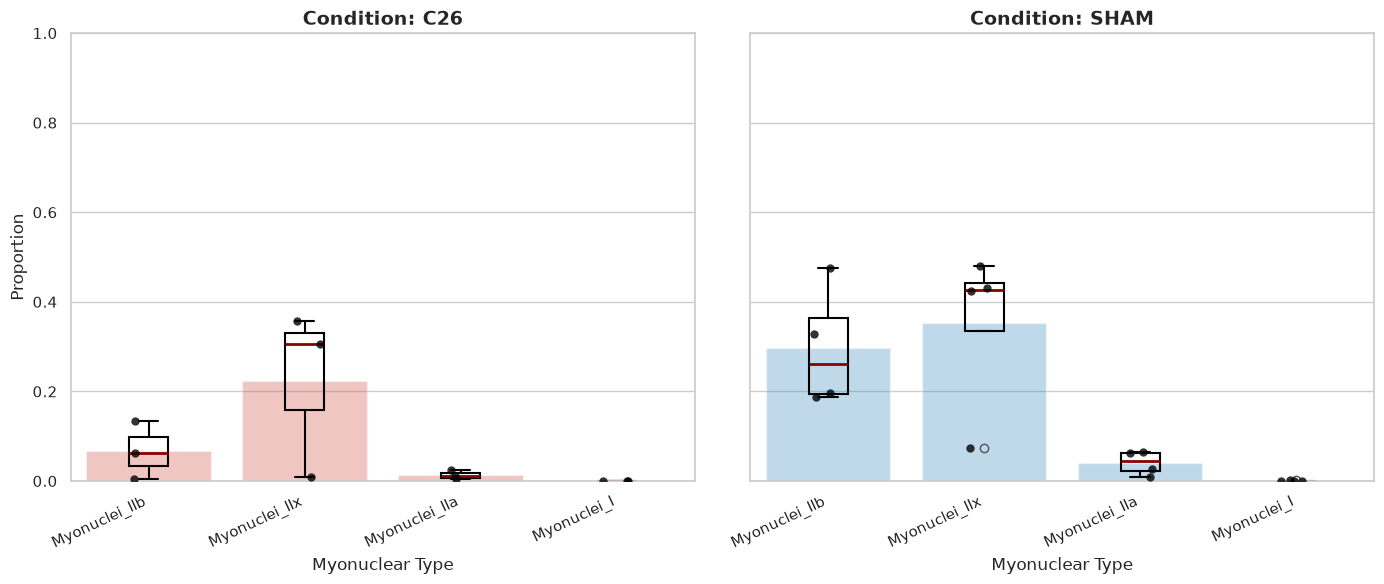

In [69]:
# Generazione del grafico (Barplot + Boxplot + Striplot)
sns.set_theme(style="whitegrid", palette="muted")

# Creiamo una figura con 2 subplot affiancati: uno per C26 e uno per SHAM
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

conditions = ['C26', 'SHAM']
colors = {'C26': '#e74c3c', 'SHAM': '#3498db'} # Rosso/Arancio per C26, Blu per SHAM

for ax, cond in zip(axes, conditions):
    df_cond = df_all[df_all['condition'] == cond]
    
    if df_cond.empty:
        print(f"⚠️ Nessun dato trovato per la condizione {cond}")
        continue
        
    # A. BARPLOT PRINCIPALE: rappresenta la MEDIA delle proporzioni
    sns.barplot(
        data=df_cond,
        x='Myonuclear_Type',
        y='Proportion',
        order=myo_order,
        ax=ax,
        color=colors[cond],
        alpha=0.35,          # Trasparenza per far risaltare il boxplot
        errorbar=None        # Rimuove le barre d'errore automatiche
    )
    
    # B. BOXPLOT SOVRAPPOSTO: mostra la distribuzione/variabilità tra campioni
    sns.boxplot(
        data=df_cond,
        x='Myonuclear_Type',
        y='Proportion',
        order=myo_order,
        ax=ax,
        width=0.25,          # Boxplot più stretto della barra
        boxprops=dict(facecolor='none', edgecolor='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5),
        medianprops=dict(color='darkred', linewidth=2) # Linea della mediana
    )
    
    # C. STRIPPLOT: punti singoli per ciascun blocco/replica
    sns.stripplot(
        data=df_cond,
        x='Myonuclear_Type',
        y='Proportion',
        order=myo_order,
        ax=ax,
        color='black',
        size=6,
        jitter=0.1,
        alpha=0.8
    )
    
    # Personalizzazione estetica del subplot
    ax.set_title(f"Condition: {cond}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Myonuclear Type", fontsize=12)
    ax.set_ylabel("Proportion", fontsize=12)
    ax.set_ylim(0, 1.0) # Le proporzioni vanno da 0 a 1 (o cambia a 100 se in %)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')

plt.tight_layout()
#plt.savefig("myonuclear_proportions_means_and_distributions.png", dpi=300)
plt.show()

In [70]:
print('ok')

ok
